# LINCS v5

Note: Must be run using `Python 3.10` environment to allow use of `cmapPy`

# Packages

In [1]:
from cmapPy.pandasGEXpress import parse
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import os
import pandas as pd
from pathlib import Path
import pickle
import seaborn as sns

# Directories

In [2]:
# Get current working directory
PATH = Path.cwd()

# Set WORK
WORK = PATH.parents[1]

# Set DATA
DATA = WORK / 'data'
# Set DATA_IN
DATA_IN = DATA / 'canada' / 'input'
# Set DATA_OUT
DATA_OUT = DATA / 'canada' / 'output'

# Set GRAPH
GRAPH = WORK / 'graphs'
# Set GRAPH_OUT
GRAPH_OUT = GRAPH / 'canada'

# Set PLOT
PLOT = WORK / 'plots'
# Set PLOT_OUT
PLOT_OUT = PLOT / 'canada'

# Files

In [170]:
# Set STRING files
STRING_EDGES = DATA_IN / '9606.protein.physical.links.full.v12.0.txt.gz' 
STRING_INFO = DATA_IN / '9606.protein.info.v12.0.txt.gz' 

# Set LINCS files
LINCS_DATA = str(DATA_IN / 'LDS-1481_1.0.gctx')                             # Changed to string for cmapPy
LINCS_INFO = DATA_IN / 'GSE92742_Broad_LINCS_sig_info.txt' 
LINCS_GENE = DATA_IN / 'GSE92742_Broad_LINCS_gene_info.txt' 

# Functions

# Pre-processing

## STRING

### Edges

In [171]:
# Load data
string_edges = pd.read_csv(STRING_EDGES, compression = 'gzip', sep = ' ')
# Show data
string_edges.head()

,protein1,protein2,homology,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,0,312,0,0,0,0,0,311
1,9606.ENSP00000000233,9606.ENSP00000226004,0,162,0,0,0,0,0,161
2,9606.ENSP00000000233,9606.ENSP00000434442,0,0,0,500,0,0,0,499
3,9606.ENSP00000000233,9606.ENSP00000262455,0,531,0,0,0,0,0,531
4,9606.ENSP00000000233,9606.ENSP00000303145,0,0,0,500,0,0,0,499


### Info

In [172]:
# Load data
string_info = pd.read_csv(STRING_INFO, compression = 'gzip', sep = '\t')
# Show data
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


### `df_string`

In [173]:
# Variables
source_column = 'protein1'
target_column = 'protein2'
score_column = 'combined_score'
id_column = '#string_protein_id'
taxon_id = '9606.'

In [174]:
# Copy edgelist
df_string = string_edges.copy(deep = True)
# Isolate columns
df_string = df_string[[source_column, target_column, score_column]]

# Rename columns for merge
string_info.rename(columns = {id_column : source_column}, inplace = True)
# Merge
df_string = pd.merge(df_string, string_info[[source_column, 'preferred_name', 'annotation']], how = 'left', on = source_column)
# Rename columns for merge
string_info.rename(columns = {source_column : target_column}, inplace = True)
# Merge
df_string = pd.merge(df_string, string_info[[target_column, 'preferred_name', 'annotation']], how = 'left', on = target_column)
# Reset column names
string_info.rename(columns = {target_column : id_column}, inplace = True)

# Rename columns
old_names = df_string.columns
new_names = ['source_id', 'target_id', 'weight', 'source', 'source_annot', 'target', 'target_annot']
df_string.rename(columns = dict(zip(old_names, new_names)), inplace = True)

# Remove taxon ID
for column in ['source_id', 'target_id']:
    df_string[column] = df_string[column].str.replace(taxon_id, '')

# Set column order
column_order = ['source', 'target', 'weight', 'source_id', 'target_id', 'source_annot', 'target_annot']
df_string = df_string[column_order]

# Save data
df_string.to_csv(DATA_OUT / 'df_string.csv', index = False)

# Show data
df_string.head()

,source,target,weight,source_id,target_id,source_annot,target_annot
0,ARF5,NT5E,311,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...
1,ARF5,DUSP3,161,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...
2,ARF5,ARFGAP2,499,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...
3,ARF5,ERP44,531,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...
4,ARF5,TMED10,499,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...


## LINCS

### `df_lincs_info`

In [175]:
# Load data
df_lincs_info = pd.read_csv(LINCS_INFO, sep = '\t')
# Rename columns
df_lincs_info.rename(columns = {'pert_id' : 'perturbagen_id', 'pert_iname' : 'perturbagen_name'}, inplace = True)
# Save data
df_lincs_info.to_csv(DATA_OUT / 'df_lincs_info.csv', index = False)
# Show data
df_lincs_info.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_3364\1484561403.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lincs_info = pd.read_csv(LINCS_INFO, sep = '\t')


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
0,AML001_CD34_24H:A05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05
1,AML001_CD34_24H:A06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:A06
2,AML001_CD34_24H:B05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:B05|AML001_CD34_24H_X...
3,AML001_CD34_24H:B06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:B06
4,AML001_CD34_24H:BRD-A03772856:0.37037,BRD-A03772856,BRD-A03772856,trt_cp,CD34,0.37037,µM,500 nM,24,h,24 h,AML001_CD34_24H_X1_F1B10:J04|AML001_CD34_24H_X...


### `df_lincs_perturbagens`

In [176]:
# Isolate columns
df_lincs_perturbagens = df_lincs_info[['perturbagen_id', 'perturbagen_name']]
# Remove duplicates
df_lincs_perturbagens.drop_duplicates(inplace = True, ignore_index = True)
# Generate mapping dictionary for later use
# lincs_perturbagens_map = dict(zip(df_lincs_info['perturbagen_id'], df_lincs_info['perturbagen_name']))
# Save data
df_lincs_perturbagens.to_csv(DATA_OUT / 'df_lincs_perturbagens.csv', index = False)
# Show data
df_lincs_perturbagens.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_3364\3470208279.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lincs_perturbagens.drop_duplicates(inplace = True, ignore_index = True)


,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


### `df_lincs_genes`

In [177]:
# Load data
df_lincs_genes = pd.read_csv(LINCS_GENE, sep = '\t')
# Rename columns
df_lincs_genes.rename(columns = {'pr_gene_id' : 'rid', 'pr_gene_symbol' : 'gene_name', 'pr_gene_title' : 'gene_desc', 'pr_is_lm' : 'landmark', 'pr_is_bing' : 'inferred'}, inplace = True)
# Save data
df_lincs_genes.to_csv(DATA_OUT / 'df_lincs_genes.csv', index = False)
# Show data
df_lincs_genes.head()

,rid,gene_name,gene_desc,landmark,inferred
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


### `df_lincs_landmark`

In [178]:
# Load data
df_lincs_genes = pd.read_csv(DATA_OUT / 'df_lincs_genes.csv')
# Extract landmark gene data
df_lincs_landmark = df_lincs_genes[df_lincs_genes['landmark'] == 1]
# Save data
df_lincs_landmark.to_csv(DATA_OUT / 'df_lincs_landmark.csv', index = False)
# Show data
df_lincs_landmark.head()

,rid,gene_name,gene_desc,landmark,inferred
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
25,6193,RPS5,ribosomal protein S5,1,1
43,23,ABCF1,ATP binding cassette subfamily F member 1,1,1
49,9552,SPAG7,sperm associated antigen 7,1,1


### `df_lincs_info_filter`

In [179]:
# Variables
filter_cells = ['HT29']
filter_timepoints = [6, 24]
filter_doses = [10]

In [ ]:
# Load data
df_lincs_info = pd.read_csv(DATA_OUT / 'df_lincs_info.csv')

# Filter data
df_lincs_info_filter = df_lincs_info[(df_lincs_info['cell_id'].isin(filter_cells)) &
                                     (df_lincs_info['pert_time'].isin(filter_timepoints)) &
                                     (df_lincs_info['pert_dose'].isin(filter_doses))]

# Save data
df_lincs_info_filter.to_csv(DATA_OUT / 'df_lincs_info_filter.csv', index = False)
# Show data
df_lincs_info_filter.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_3364\4069653484.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lincs_info = pd.read_csv(DATA_OUT / 'df_lincs_info.csv')


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
50538,CPC004_HT29_6H:BRD-A00546892-001-01-8:10,BRD-A00546892,biperiden,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:J19|CPC004_HT...
50539,CPC004_HT29_6H:BRD-A00993607-003-15-4:10,BRD-A00993607,alprenolol,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:E24|CPC004_HT...
50540,CPC004_HT29_6H:BRD-A01593789-001-02-3:10,BRD-A01593789,chlormadinone-acetate,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:H21|CPC004_HT...
50541,CPC004_HT29_6H:BRD-A01643550-001-03-1:10,BRD-A01643550,prednisolone-acetate,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:P13|CPC004_HT...
50542,CPC004_HT29_6H:BRD-A02006392-001-09-9:10,BRD-A02006392,nitrendipine,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:F14|CPC004_HT...


### `df_lincs_sigids`

In [181]:
# Load data
df_lincs_info_filter = pd.read_csv(DATA_OUT / 'df_lincs_info_filter.csv')
# Extract signature IDs
df_lincs_sigids = pd.DataFrame(df_lincs_info_filter['sig_id'], columns = ['sig_id'])

# Report
print(f'{len(df_lincs_sigids):,} signature IDs found after filter \n')

# Save data
df_lincs_sigids.to_csv(DATA_OUT / 'df_lincs_sigids.csv', index = False)
# Show data
df_lincs_sigids.head()

7,102 signature IDs found after filter 



,sig_id
0,CPC004_HT29_6H:BRD-A00546892-001-01-8:10
1,CPC004_HT29_6H:BRD-A00993607-003-15-4:10
2,CPC004_HT29_6H:BRD-A01593789-001-02-3:10
3,CPC004_HT29_6H:BRD-A01643550-001-03-1:10
4,CPC004_HT29_6H:BRD-A02006392-001-09-9:10


### `df_lincs`

In [182]:
# Load data
df_lincs_sigids = pd.read_csv(DATA_OUT / 'df_lincs_sigids.csv')
# Extract signature IDs
list_lincs_ids = df_lincs_sigids['sig_id'].tolist()

# Filter LINCS data
df_lincs = parse.parse(LINCS_DATA, cid = list_lincs_ids).data_df
# Show data
df_lincs.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


cid,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,CPC004_HT29_6H:BRD-K03670461-001-02-0:10,CPC004_HT29_6H:BRD-K36737713-001-01-6:10,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC004_HT29_6H:BRD-A14966924-001-03-0:10,CPC004_HT29_6H:BRD-K79131256-001-08-8:10,...,PCLB003_HT29_24H:BRD-K64024097-001-02-8:10,PCLB003_HT29_24H:BRD-K64106162-001-02-3:10,PCLB003_HT29_24H:BRD-K16956545-001-01-0:10,PCLB003_HT29_24H:BRD-K78431006-001-05-2:10,PCLB003_HT29_24H:BRD-K63828191-003-23-0:10,PCLB003_HT29_24H:BRD-K93754473-001-17-7:10,PCLB003_HT29_24H:BRD-A52530684-003-01-7:10,PCLB003_HT29_24H:BRD-A75409952-001-01-6:10,PCLB003_HT29_24H:BRD-K04466929-001-05-1:10,PCLB003_HT29_24H:BRD-K17953061-001-10-1:10
rid,,,,,,,,,,,,,,,,,,,,,
5720,-2.999525,-0.623000,0.141888,-0.752267,0.380861,0.076565,-0.749507,-0.284185,0.664252,-0.007322,...,-1.151560,-0.000140,0.589545,-4.135498,-1.515962,-0.059089,2.775635,1.046220,2.3866,0.1313
466,-1.922989,-1.483600,-0.004969,-1.476633,0.828392,0.913175,-0.654432,0.067755,0.684563,1.565995,...,0.390024,0.443335,0.784108,0.183998,-0.215364,1.981584,-1.622547,0.435221,-0.3456,-1.8265
6009,-0.742801,-0.406733,-0.614206,-3.505600,0.381193,0.356511,-0.324873,-0.300248,0.563278,1.232050,...,-0.415272,-0.182099,0.496713,0.417429,2.301637,-0.266856,-2.440649,-0.030544,0.3245,1.5535
2309,-1.567428,0.373000,0.258819,0.750733,-0.013309,-0.172938,-0.571196,0.091755,0.042603,-1.011316,...,0.054832,-0.706762,-0.519995,-0.955052,0.773697,-0.423104,-2.262421,0.163010,0.2551,-2.9476
387,-2.488176,-0.959167,0.737944,-1.150100,-0.292709,-1.357093,0.885794,-0.627101,-0.029998,-0.127312,...,0.611129,0.537418,0.410376,-1.394473,1.186869,-0.120520,-0.581043,-1.971128,-0.7342,-0.3201


#### `df_lincs_meta`

In [183]:
# Extract columns
list_cids = list(df_lincs.columns)
# Initialise dataframe
df_lincs_meta = pd.DataFrame(list_cids, columns = ['cid'])
# Copy column
df_lincs_meta['metadata'] = df_lincs_meta['cid']
# Extract perturbagen ID
df_lincs_meta['metadata'] = df_lincs_meta['metadata'].str.replace(r'-(?:[^-]+-){2}[^-]+(?=:\d+$)', '', regex = True)
# Split 'metadata' column
df_lincs_meta[['data', 'perturbagen_id', 'dose']] = df_lincs_meta['metadata'].str.split(':', expand = True)
# Split 'data' column
df_lincs_meta[['dataset', 'cell_line', 'timepoint']] = df_lincs_meta['data'].str.split('_', expand = True)
# Drop columns
df_lincs_meta.drop(columns = ['metadata', 'data'], inplace = True)

# Load data
df_lincs_perturbagens = pd.read_csv(DATA_OUT / 'df_lincs_perturbagens.csv')
# Merge
df_lincs_meta = pd.merge(df_lincs_meta, df_lincs_perturbagens, how = 'left', on = 'perturbagen_id')

# Show data
df_lincs_meta.head()

,cid,perturbagen_id,dose,dataset,cell_line,timepoint,perturbagen_name
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,BRD-A85280935,10,CPC005,HT29,6H,quinpirole
1,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,BRD-A07824748,10,CPC005,HT29,6H,flavanone
2,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,BRD-K20482099,10,CPC004,HT29,6H,rutin
3,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,BRD-K62929068,10,CPC005,HT29,6H,6-benzylaminopurine
4,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,BRD-K43405658,10,CPC005,HT29,6H,tyrphostin-AG-527


#### Finalise data

In [184]:
# Load data
df_lincs_genes = pd.read_csv(DATA_OUT / 'df_lincs_genes.csv')

# Reset `df_lincs` index
df_lincs.reset_index(inplace = True)
# Assert datatypes
df_lincs['rid'] = df_lincs['rid'].astype(int)
df_lincs_genes['rid'] = df_lincs_genes['rid'].astype(int)
# Merge
df_lincs = pd.merge(df_lincs, df_lincs_genes[['rid', 'gene_name', 'gene_desc', 'landmark']], how = 'left', on = 'rid')
# Melt on gene expression values
df_lincs = df_lincs.melt(id_vars = ['rid', 'gene_name', 'gene_desc', 'landmark'], value_vars = list_cids, var_name = 'cid', value_name = 'value')
# Merge with metadata
df_lincs = pd.merge(df_lincs, df_lincs_meta, how = 'left', on = 'cid')
# Reorder columns
df_lincs = df_lincs[['cid', 'dataset', 'cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'rid', 'gene_name', 'gene_desc', 'landmark', 'value']]
# Rename columns
df_lincs.rename(columns = {'rid' : 'gene_id', 'value' : 'dexp'}, inplace = True)

# Save data
with open(DATA_OUT / 'df_lincs.pkl', 'wb') as f:
    pickle.dump(df_lincs, f)

# Show data
df_lincs.head()

,cid,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,landmark,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,1,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,1,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,1,-2.488176


### `df_lincs_filter`

In [3]:
# Load data
with open(DATA_OUT / 'df_lincs.pkl', 'rb') as f:
    df_lincs = pickle.load(f)

# Get unique perturbagen IDs
len_unique_ids = len(pd.unique(df_lincs['perturbagen_id']))
# Count number of timepoints per perturbagen ID
timepoint_count = df_lincs.groupby(by = 'perturbagen_id')['timepoint'].nunique()
# Count number of perturbagen IDs with 2 timepoint data entries
list_timepoint_ids = timepoint_count[timepoint_count == 2].index.tolist()
# Calculate variables
len_timepoint_ids = len(list_timepoint_ids)
percent_timepoint_ids = len_timepoint_ids / len_unique_ids * 100

# Report
print(f'{percent_timepoint_ids:.2f}% of perturbagens ({len_timepoint_ids:,}/{len_unique_ids:,}) with data at all desired timepoints')

18.36% of perturbagens (938/5,108) with data at all desired timepoints


In [9]:
# Filter data
df_lincs_filter = df_lincs[df_lincs['perturbagen_id'].isin(list_timepoint_ids)]
df_lincs_filter = df_lincs_filter[df_lincs_filter['landmark'] == 1]

# Save data
with open(DATA_OUT / 'df_lincs_filter.pkl', 'wb') as f:
    pickle.dump(df_lincs_filter, f)

# Show data
df_lincs_filter.head()

,cid,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,landmark,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,1,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,1,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,1,-2.488176


## Base Graph

In [52]:
# Variables
score_filter = 0

In [53]:
# Load data
df_string = pd.read_csv(DATA_OUT / 'df_string.csv')
# Generate graph object
graph_base = nx.from_pandas_edgelist(df_string[df_string.columns[0:3]], source = 'source', target = 'target', edge_attr = 'weight')

# Record number of nodes and edges
num_nodes = len(graph_base.nodes)
num_edges = len(graph_base.edges)

# Filter by edge weights
graph_base.remove_edges_from([(source, target) for source, target, weight in graph_base.edges(data = 'weight') if weight < score_filter])
# Remove unconnected nodes
graph_base.remove_nodes_from(list(nx.isolates(graph_base)))

# Record number of nodes and edges
num_nodes_filter = len(graph_base.nodes)
num_edges_filter = len(graph_base.edges)
# Calculate variables
percent_nodes = num_nodes_filter / num_nodes * 100
percent_edges = num_edges_filter / num_edges * 100

# Report
print(f'Base graph of {num_nodes:,} nodes and {num_edges:,} edges generated')
print(f'Filtered for edges with a confidence score >= {score_filter}')
print(f'{percent_nodes:.2f}% nodes ({num_nodes_filter:,}/{num_nodes:,}) and {percent_edges:.2f}% edges ({num_edges_filter:,}/{num_edges:,}) remain')
print()

# Save graph
with open(GRAPH_OUT / 'graph_base.pkl', 'wb') as f:
    pickle.dump(graph_base, f)

Base graph of 18,767 nodes and 738,805 edges generated
Filtered for edges with a confidence score >= 0
100.00% nodes (18,767/18,767) and 100.00% edges (738,805/738,805) remain



## Landmark Graph

In [ ]:
# Load graph
with open(GRAPH_OUT / 'graph_base.pkl', 'rb') as f:
    graph_base = pickle.load(f)

# Load data
df_lincs_landmark = pd.read_csv(DATA_OUT / 'df_lincs_landmark.csv')

# Extract landmark gene IDs
list_landmark = list(pd.unique(df_lincs_landmark['gene_name']))
# Extract nodelist
list_nodes = list(graph_base.nodes)
# Get landmark nodes not found in graph_base
list_missing = set(list_landmark) - set(list_nodes)
# Get overlapping landmark genes
list_overlap = set(list_landmark).intersection(set(list_nodes))

# Set nodes to remove
list_remove = set(list_nodes) - set(list_landmark)
# Copy graph
graph_lm = graph_base.copy()
# Remove nodes
graph_lm.remove_nodes_from(list_remove)
# Extract isolated nodes
list_isolates = list(nx.isolates(graph_lm))
# Remove unconnected nodes
graph_lm.remove_nodes_from(list_isolates)

# Calculate variables
len_landmark = len(list_landmark)
len_missing = len(list_missing)
len_overlap = len(list_overlap)
len_nodes = len(graph_base.nodes)
len_nodes_lm = len(graph_lm.nodes)
len_isolates = len(list_isolates)
percent_missing = len_missing / len_landmark * 100 
percent_overlap = len_overlap / len_landmark * 100
percent_isolates = len_isolates / len_overlap * 100
percent_nodes = len_nodes_lm / len_nodes * 100
percent_landmark = len_nodes_lm / len_landmark * 100

# Report
print(f'{len_landmark:,} landmark genes identified')
print(f'{percent_overlap:.2f}% of landmark genes ({len_overlap:,}/{len_landmark:,}) found in graph_base')
print(f'{percent_isolates:.2f}% of landmark genes ({len_isolates:,}/{len_overlap:,}) in subgraph found as isolates')
print(f'{percent_nodes:.2f}% of nodes ({len_nodes_lm:,}/{len_nodes:,}) remain after filtering graph_base for landmark nodes and removing isolates')
print(f'{percent_landmark:.2f}% of landmark genes ({len_nodes_lm:,}/{len_landmark:,}) retained in graph_lm')

# Save graph
with open(GRAPH_OUT / 'graph_lm.pkl', 'wb') as f:
    pickle.dump(graph_lm, f)

978 landmark genes identified
97.03% of landmark genes (949/978) found in graph_base
2.95% of landmark genes (28/949) in subgraph found as isolates
4.91% of nodes (921/18,767) remain after filtering graph_base for landmark nodes and removing isolates
94.17% of landmark genes (921/978) retained in graph_lm


In [64]:
# Extract landmark genes missing from graph_base
df_missing = df_lincs_landmark[df_lincs_landmark['gene_name'].isin(list_missing)].reset_index(drop = True)
# Extract landmark data for isolates
df_isolates = df_lincs_landmark[df_lincs_landmark['gene_name'].isin(list_isolates)].reset_index(drop = True)

# Drop columns
for df in [df_missing, df_isolates]:
    df.drop(columns = ['landmark', 'inferred'], inplace = True)

# Save data
df_missing.to_csv(DATA_OUT / 'df_missing.csv', index = False)
df_isolates.to_csv(DATA_OUT / 'df_isolates.csv', index = False)
# Show data
df_isolates.head()

,rid,gene_name,gene_desc
0,9552,SPAG7,sperm associated antigen 7
1,10904,BLCAP,bladder cancer associated protein
2,9697,TRAM2,translocation associated membrane protein 2
3,5373,PMM2,phosphomannomutase 2
4,8869,ST3GAL5,"ST3 beta-galactoside alpha-2,3-sialyltransfera..."


## Context Graphs

In [11]:
# Load graph
with open(GRAPH_OUT / 'graph_lm.pkl', 'rb') as f:
    graph_lm = pickle.load(f)

# Load data
with open(DATA_OUT / 'df_lincs_filter.pkl', 'rb') as f:
    df_lincs_filter = pickle.load(f)

In [42]:
# Define unique variable lists
unique_cells = list(pd.unique(df_lincs_filter['cell_line']))
unique_perturbagens = list(pd.unique(df_lincs_filter['perturbagen_id']))[0:5]
unique_timepoints = list(pd.unique(df_lincs_filter['timepoint']))
unique_doses = list(pd.unique(df_lincs_filter['dose']))

In [44]:
# Iterate through combinations of unique values
for cell_line, perturbagen_id, dose, timepoint in itertools.product(unique_cells, unique_perturbagens, unique_doses, unique_timepoints):

    # Slice data
    df_slice = df_lincs_filter[(df_lincs_filter['cell_line'] == cell_line) &
                               (df_lincs_filter['perturbagen_id'] == perturbagen_id) &
                               (df_lincs_filter['dose'] == dose) &
                               (df_lincs_filter['timepoint'] == timepoint)]
    
    # Set index
    df_slice.set_index('gene_name', inplace = True)

    # Extract columns
    df_slice = df_slice[['dexp']]

    # Copy graph_lm
    graph_slice = graph_lm.copy()
    # Set node attributes
    nx.set_node_attributes(graph_slice, df_slice['dexp'].to_dict(), name = 'dexp')

    # Save graph
    with open(GRAPH_OUT / f'{cell_line}_{perturbagen_id}_{dose}_{timepoint}.pkl', 'wb') as f:
        pickle.dump(graph_slice, f)

# Analysis

## `graph_landmark`

### Isolated node degree

How well connected are the isolated nodes removed when making `graph_landmark`?
- B/W plot of node degree w/ overlayed df_missing and df_isolates genes

In [124]:
# Load graph
with open(GRAPH_OUT / 'graph_base.pkl', 'rb') as f:
    graph_base = pickle.load(f)

# Load data
df_isolates = pd.read_csv(DATA_OUT / 'df_isolates.csv')

# Extract isolate genes
list_isolates = list(pd.unique(df_isolates['gene_name']))
# Get node list without isolates
list_difference = list(set(list(graph_base.nodes)) - set(list_isolates))

# Get node degrees
degrees_base_all = [(node, graph_base.degree[node], 'Base (all)') for node in graph_base.nodes]
degrees_base_without = [(node, graph_base.degree[node], 'Base (without isolates)') for node in graph_base.nodes if node in list_difference] 
degrees_isolates = [(node, graph_base.degree[node], 'Isolates') for node in graph_base.nodes if node in list_isolates]

# Initialise dataframe
df_plot = pd.DataFrame()
# Assign data
for degreelist in [degrees_base_all, degrees_base_without, degrees_isolates]:
    df = pd.DataFrame(degreelist, columns = ['node', 'degree', 'type'])
    df_plot = pd.concat([df_plot, df], ignore_index = True)

# Show data
df_plot.head()

,node,degree,type
0,ARF5,123,Base (all)
1,NT5E,100,Base (all)
2,DUSP3,45,Base (all)
3,ARFGAP2,63,Base (all)
4,ERP44,139,Base (all)


Text(0, 0.5, '')

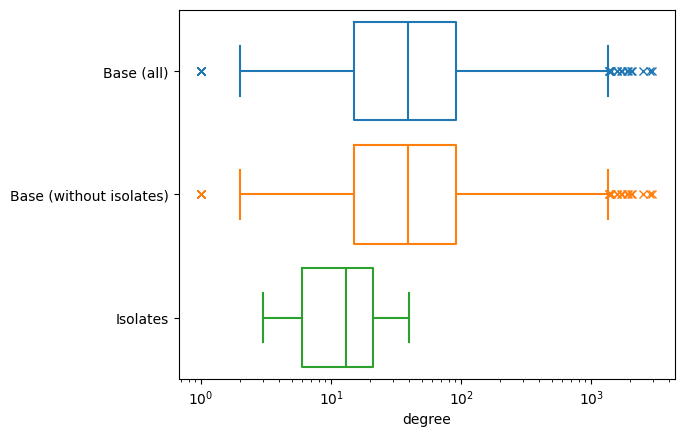

In [125]:
# Plot
sns.boxplot(df_plot, x = 'degree', y = 'type', orient = 'h', log_scale = True, hue = 'type', fill = False, showcaps = True, flierprops = {'marker' : 'x'})
plt.ylabel('')

### Missing/Isolated node enrichment

Are there any specific processes enriched in the missing and/or isolated landmark genes?
- DAVID enrichment of missing and isolated genes
- Which statistically enriched processes (if any) are exclusive or common to both?
- Clustermap of process vs gene type

In [134]:
# Load graph
with open(GRAPH_OUT / 'graph_base.pkl', 'rb') as f:
    graph_base = pickle.load(f)

# Load data
df_missing = pd.read_csv(DATA_OUT / 'df_missing.csv')
df_isolates = pd.read_csv(DATA_OUT / 'df_isolates.csv')

# Extract full nodelist
list_nodes = [node for node in graph_base.nodes]
# Convert to dataframe
df_nodes = pd.DataFrame(list_nodes, columns = ['gene'])

# Save data
df_missing['gene_name'].to_csv(DATA_OUT / 'david_missing.txt', header = False, index = False)
df_isolates['gene_name'].to_csv(DATA_OUT / 'david_isolates.txt', header = False, index = False)
df_nodes['gene'].to_csv(DATA_OUT / 'david_background.txt', header = False, index = False)

- Only 2 missing genes found by DAVID (TCTA, SACM1L)
    - No significant results returned

- All isolated nodes (28) found by DAVID
- Running isolated nodes vs human background only returned 2 records in GOTERM_MF_DIRECT
    - metal ion binding, 9 genes, 3.3e-2
    - glycosyltransferase activity, 2 genes, 8.8e-2
    - Neither was significant when using the Benjamini adjusted pvalue

- Full graph_base nodelist was submitted to DAVID (18,767)
- 18,364 genes found by DAVID (403 missing)
- The same 2 records in GOTERM_MF_DIRECT were returned, neither significant with adjust p-value
    - metal ion binding, 9 genes, 4.4e-2
    - glycosyltransferase activity, 2 genes, 9.1e-2

### Remaining landmark node enrichment

Are there any processes enriched in the nodes retained in graph_lm?

In [ ]:
# Load graph

# Extract nodes

# Save data

### Visualisation

Plot `graph_landmark`

1 connected components found in graph_lm


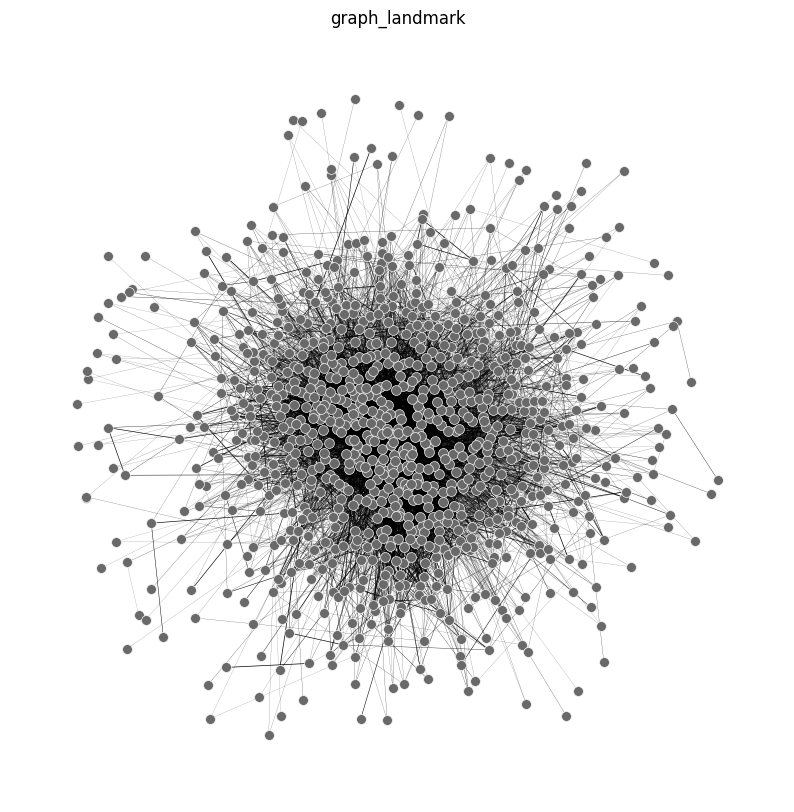

In [163]:
# Load graph
with open(GRAPH_OUT / 'graph_lm.pkl', 'rb') as f:
    graph_lm = pickle.load(f)

# Calculate positional data
pos_lm = nx.spring_layout(graph_lm, k = 2)

# Get edge weights
list_weights = [graph_lm[source][target]['weight'] / 2000 for source, target in graph_lm.edges()]

# Get number of connected components
num_cc = nx.number_connected_components(graph_lm)
print(f'{num_cc:,} connected components found in graph_lm')

# Plot
plt.figure(figsize = (10,10))
plt.title('graph_landmark')
plt.axis('off')

nx.draw_networkx_edges(graph_lm, pos = pos_lm, width = list_weights)
nx.draw_networkx_nodes(graph_lm, pos = pos_lm, node_size = 50, node_color = 'dimgrey', edgecolors = 'whitesmoke', linewidths = 0.5)

plt.show()

## `context_graphs`

Graph > GIN > Contrastive learning (no labels) > Embedding > Classifier > PDExplainer

Learns representation, trains using known drugs, explains the most important areas

In [ ]:
# Install packages (CUDA GPU-acceleration capable)
# PyTorch
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# PyTorch Geometric
# pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.7.0+cu126.html
# PyTorch Geometric 2
# pip install torch_geometric
# Scikit Learn
#!pip install scikit-learn

In [53]:
# Packages
import torch
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import networkx as nx
import numpy as np
import random

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\roman\AppData\Lo

In [ ]:
# Get node degree from graph_lm
# Identify ego node for subgraphs

In [ ]:
# Iterate through HT29 graphs
# Isolate subgraph based on ego node
# Save graphs

In [ ]:
# Load subgraphs

In [ ]:
# GIN encoder